In [23]:
"""
Electron Source Numerical Modeling for Electric Propulsion Systems


Tasks implemented:
1. Thermionic emission model (Richardson-Dushman + Schottky)
2. Sheath current balance with ionization
3. 1D plasma column extension
4. Validation against literature trends

Author: Suryansh Raj
Date: January 2026
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, newton
from scipy.integrate import odeint
import warnings
warnings.filterwarnings('ignore')


# Fundamental constants
e = 1.602e-19           # Elementary charge
k_B = 1.381e-23         #Boltzmann constant
eps_0 = 8.854e-12       # Permittivity of free space
m_e = 9.109e-31         # Electron mass
m_Xe = 2.18e-25         # Xenon mass
eV_to_J = 1.602e-19     # eV to Joules conversion

# Emission constants (LaB6 cathode)
A_R = 20e4              # Richardson constant
W_0 = 2.6               # Work function

# Plasma parameters
T_e_default = 3.0       # Electron temperature
n_discharge = 1e17      # Discharge plasma density

In [24]:
# TASK 1: EMISSION MODEL


class EmissionModel:
    """
    Thermionic and field emission models for electron sources.
    """

    def __init__(self, emission_type='thermionic'):
        """
        Initialize emission model.

        Parameters:

            emission_type : str
                'thermionic' or 'field'; 'field' removed as I chose to proceed with THC as my
                emission mechanism.
        """
        self.emission_type = emission_type

    def schottky_lowering(self, E_field):
        """
        Calculate Schottky barrier lowering.

        Parameters:

            E_field : float or array
                Electric field at cathode surface

        Returns:

        delta_W : float or array
            Work function reduction
        """
        # Prevent negative field values
        E_field = np.maximum(E_field, 0)

        # Schottky effect: W = sqrt(e^3*E / 4*pi*eps)
        delta_W = np.sqrt(e**3 * E_field / (4 * np.pi * eps_0)) / eV_to_J
        return delta_W

    def thermionic_emission(self, T, E_field=0):
        """
        Richardson-Dushman equation with Schottky correction.

        J_em = A*T^2 * exp(-W_eff/kT)
        W_eff = W - W_schottky

        Parameters:

              T : float or array
                  Temperature
              E_field : float or array
                  Surface electric field

        Returns:

              J_em : float or array
                  Emission current density
        """
        # Calculate effective work function
        delta_W = self.schottky_lowering(E_field)
        W_eff = W_0 - delta_W

        # Richardson-Dushman equation
        J_em = A_R * T**2 * np.exp(-W_eff * eV_to_J / (k_B * T))

        return J_em



    def get_emission_current(self, T, V_sheath, cathode_area, d_sheath=1e-5):
        """
        Calculate total emission current.

        Parameters:

              T : float
                  Temperature
              V_sheath : float
                  Sheath voltage
              cathode_area : float
                  Emitting area
              d_sheath : float
                  Sheath thickness estimate

        Returns:

              I_em : float
                  Total emission current
        """
        # Estimate electric field from sheath voltage
        E_field = V_sheath / d_sheath if d_sheath > 0 else 0

        if self.emission_type == 'thermionic':
            J_em = self.thermionic_emission(T, E_field)

        I_em = J_em * cathode_area

        return I_em

In [ ]:
# TASK 2: SHEATH CURRENT BALANCE


class SheathModel:
    """
    Plasma sheath model with current balance and ionization.
    """

    def __init__(self, T_e=3.0):
        """
        Initialize sheath model.

        Parameters:

              T_e : float
                  Electron temperature
        """
        self.T_e = T_e  # Electron temperature

    def bohm_criterion(self, n_0, V_sheath):
        """
        Apply Bohm presheath density relation.

        n_e(0) = 0.61 * n_0 * exp(-0.5 * e * V_sheath / k * T_e)

        Parameters:

              n_0 : float
                  Plasma density
              V_sheath : float
                  Sheath voltage drop

        Returns:

              n_edge : float
                  Density at sheath edge
        """
        n_edge = 0.61 * n_0 * np.exp(-0.5 * e * V_sheath / (k_B * self.T_e * eV_to_J))
        return n_edge

    def ion_current(self, n_0, V_sheath, cathode_area):
        """
        Calculate ion current to cathode (Bohm flux).

        Γ_i = n_e * c_s
        c_s = sqrt(k*T_e / M_ion) [Bohm velocity]

        Parameters:

              n_0 : float
                  Plasma density
              V_sheath : float
                  Sheath voltage
              cathode_area : float
                  Collection area

        Returns:

              I_ion : float
                  Ion current
        """
        # Bohm velocity
        c_s = np.sqrt(k_B * self.T_e * eV_to_J / m_Xe)

        # Density at sheath edge
        n_edge = self.bohm_criterion(n_0, V_sheath)

        # Ion flux and current
        Gamma_i = n_edge * c_s
        I_ion = e * Gamma_i * cathode_area

        return I_ion

    def ionization_rate(self, n_n, T_e=None):
        """
        Xenon ionization rate coefficient.

        v_iz = 10^-7 * exp(-15.8 / T_e)

        Parameters:

              n_n : float
                  Neutral density
              T_e : float
                  Electron temperature

        Returns:

              nu_iz : float
                  Ionization frequency
        """
        if T_e is None:
            T_e = self.T_e

        # Cross-section fit for Xenon
        k_iz = 1e-13 * np.exp(-15.8 / T_e)

        return k_iz

    def current_balance(self, V_sheath, T, V_c, n_n, cathode_area,
                       emission_model, volume=1e-6):
        """
        Solve current balance equation.

        I_emitted = I_ion + I_net

        Parameters:

              V_sheath : float
                  Sheath voltage to solve for
              T : float
                  Cathode temperature
              V_c : float
                  Applied cathode voltage
              n_n : float
                  Neutral density
              cathode_area : float
                  Cathode area
              emission_model : EmissionModel
                  Emission model instance
              volume : float
                  Ionization volume

        Returns:

              residual : float
                  Current balance residual
        """
        # Get emission current
        I_em = emission_model.get_emission_current(T, V_sheath, cathode_area)

        # Estimate plasma density from ionization balance
        # Simplified: n_e ≈ sqrt(ν_iz * n_n * V / A * c_s)
        k_iz = self.ionization_rate(n_n)
        c_s = np.sqrt(k_B * self.T_e * eV_to_J / m_Xe)

        # Simple 0D balance
        n_0 = np.sqrt(k_iz * n_n * volume / (cathode_area * c_s))
        n_0 = min(n_0, n_discharge)  # Cap at discharge density

        # Ion current
        I_ion = self.ion_current(n_0, V_sheath, cathode_area)

        # Current balance residual
        residual = I_em - I_ion

        return residual

In [26]:
# TASK 3: 1D PLASMA COLUMN MODEL

class PlasmaColumn1D:
    """
    1D quasineutral plasma column model.
    """

    def __init__(self, length=0.05, n_cells=50, T_e=3.0):
        """
        Initialize 1D model.

        Parameters:

              length : float
                  Column length
              n_cells : int
                  Number of grid cells
              T_e : float
                  Electron temperature
        """
        self.L = length
        self.n_cells = n_cells
        self.z = np.linspace(0, length, n_cells)
        self.dz = length / (n_cells - 1)
        self.T_e = T_e

    def diffusion_coefficient(self, T_e=None):
        """
        Electron diffusion coefficient (Bohm approximation).

        D_e ≈ 0.1 * c_s * mfp
        """
        if T_e is None:
            T_e = self.T_e

        c_s = np.sqrt(k_B * T_e * eV_to_J / m_Xe)
        # Assume mean free path ~ 1 mm
        lambda_mfp = 1e-3
        D_e = 0.1 * c_s * lambda_mfp

        return D_e

    def mobility(self, T_e=None):
        """
        Electron mobility.

        mu_e = e * D_e / (k * T_e)
        """
        if T_e is None:
            T_e = self.T_e

        D_e = self.diffusion_coefficient(T_e)
        mu_e = e * D_e / (k_B * T_e * eV_to_J)

        return mu_e

    def solve_steady_state(self, n_edge, n_n, n_discharge=1e17):
        """
        Solve steady-state 1D diffusion with ionization.

        d2n_e/dz2 = (ν_iz * n_n - ν_rec * n_e) * n_e / D_e

        Boundary conditions:
        - z=0: n_e = n_edge (from sheath)
        - z=L: n_e = n_discharge

        Parameters:

              n_edge : float
                  Density at cathode edge
              n_n : float
                  Neutral density
              n_discharge : float
                  Discharge plasma density

        Returns:

              n_e : array
                  Electron density profile
              V_p : array
                  Plasma potential profile
        """
        # Diffusion coefficient
        D_e = self.diffusion_coefficient()

        # Ionization rate
        k_iz = 1e-13 * np.exp(-15.8 / self.T_e)
        nu_iz = k_iz * n_n

        # Recombination (simplified)
        alpha_rec = 1e-13

        # Solve using relaxation method
        n_e = np.linspace(n_edge, n_discharge, self.n_cells)

        # Iterative solver
        for iteration in range(1000):
            n_e_old = n_e.copy()

            for i in range(1, self.n_cells - 1):
                # Second derivative
                d2n_dz2 = (n_e[i+1] - 2*n_e[i] + n_e[i-1]) / self.dz**2

                # Source term
                source = (nu_iz - alpha_rec * n_e[i]) * n_e[i] / D_e

                # Update
                n_e[i] = n_e_old[i] + 0.1 * (d2n_dz2 - source) * self.dz**2
                n_e[i] = max(n_e[i], 1e14)  # Floor

            # Check convergence
            if np.max(np.abs(n_e - n_e_old)) < 1e-3 * np.mean(n_e):
                break

        # Calculate plasma potential (quasi-neutral, Boltzmann relation)
        V_p = -self.T_e * np.log(n_e / n_discharge)

        return n_e, V_p

In [27]:

# MAIN SIMULATION CLASS


class ElectronSourceSimulation:
    """
    Complete electron source model integrating all tasks.
    """

    def __init__(self, d_orifice=1e-3):
        """
        Initialize simulation.

        Parameters:

              d_orifice : float
                  Orifice diameter
        """
        self.d_orifice = d_orifice
        self.A_cathode = np.pi * (d_orifice / 2)**2

        # Initialize models
        self.emission = EmissionModel('thermionic')
        self.sheath = SheathModel(T_e=3.0)
        self.plasma_1d = PlasmaColumn1D()

    def pressure_to_density(self, pressure, T_gas=500):
        """
        Convert pressure to neutral density.

        n = p / (k * T)

        Parameters:

              pressure : float
                  Pressure
              T_gas : float
                  Gas temperature

        Returns:

              n_n : float
                  Neutral density
        """
        n_n = pressure / (k_B * T_gas)
        return n_n

    def solve_operating_point(self, T, V_c, pressure):
        """
        Solve for steady-state operating point.

        Parameters:

              T : float
                  Cathode temperature
              V_c : float
                  Cathode voltage
              pressure : float
                  Neutral pressure

        Returns:

              result : dict
                  Operating point parameters
        """
        # Convert pressure to density
        n_n = self.pressure_to_density(pressure)

        # Solve for sheath voltage
        try:
            V_sheath_guess = 5.0  # Initial guess
            V_sheath = fsolve(
                lambda V: self.sheath.current_balance(
                    V, T, V_c, n_n, self.A_cathode, self.emission
                ),
                V_sheath_guess,
                full_output=False
            )[0]

            # Ensure positive sheath voltage
            V_sheath = max(V_sheath, 0.1)

            # Calculate currents
            I_em = self.emission.get_emission_current(T, V_sheath, self.A_cathode)

            # Plasma density estimate
            k_iz = self.sheath.ionization_rate(n_n)
            c_s = np.sqrt(k_B * self.sheath.T_e * eV_to_J / m_Xe)
            volume = 1e-6
            n_0 = np.sqrt(k_iz * n_n * volume / (self.A_cathode * c_s))

            I_ion = self.sheath.ion_current(n_0, V_sheath, self.A_cathode)
            I_net = I_em - I_ion

            # Plasma potential
            V_p = V_c + V_sheath

            return {
                'V_sheath': V_sheath,
                'V_p': V_p,
                'I_em': I_em,
                'I_ion': I_ion,
                'I_net': I_net,
                'n_plasma': n_0,
                'success': True
            }

        except:
            return {
                'V_sheath': 0,
                'V_p': 0,
                'I_em': 0,
                'I_ion': 0,
                'I_net': 0,
                'n_plasma': 0,
                'success': False
            }



In [28]:
# PLOTTING AND ANALYSIS FUNCTIONS


def plot_task1_emission_curves(save=True):
    """
    Task 1: Plot emission current density vs T and V.
    Ps: cross-checked with literature.
    """
    emission = EmissionModel('thermionic')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: J_em vs T at different electric fields
    T_range = np.linspace(1200, 2000, 100)
    E_fields = [0, 1e6, 5e6, 1e7]

    for E in E_fields:
        J_em = emission.thermionic_emission(T_range, E)
        ax1.semilogy(T_range, J_em, label=f'E = {E/1e6:.0f} MV/m', linewidth=2)

    ax1.set_xlabel('Temperature [K]', fontsize=12)
    ax1.set_ylabel('Emission Current Density [A/m²]', fontsize=12)
    ax1.set_title('Thermionic Emission vs Temperature\n(Richardson-Dushman + Schottky)', fontsize=13)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: J_em vs E_field at different temperatures
    E_range = np.logspace(5, 7.5, 100)
    temperatures = [1400, 1500, 1600, 1700, 1800]

    for T in temperatures:
        J_em = emission.thermionic_emission(T, E_range)
        ax2.loglog(E_range, J_em, label=f'T = {T} K', linewidth=2)

    ax2.set_xlabel('Electric Field [V/m]', fontsize=12)
    ax2.set_ylabel('Emission Current Density [A/m²]', fontsize=12)
    ax2.set_title('Emission vs Electric Field\n(Schottky Enhancement)', fontsize=13)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()



def plot_task2_iv_characteristics(save=True):
    """
    Task 2: Plot I-V characteristics and operating maps.
    """
    sim = ElectronSourceSimulation(d_orifice=1e-3)

    # I-V curves for different temperatures
    V_c_range = np.linspace(5, 30, 26)
    temperatures = [1400, 1500, 1600, 1700, 1800]
    pressure = 5.0  # Pa

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))

    # Plot 1: I_net vs V_c at different temperatures
    for T in temperatures:
        I_net_list = []
        for V_c in V_c_range:
            result = sim.solve_operating_point(T, V_c, pressure)
            I_net_list.append(result['I_net'])

        ax1.plot(V_c_range, I_net_list, 'o-', label=f'{T} K', linewidth=2, markersize=4)

    ax1.set_xlabel('Cathode Voltage [V]', fontsize=12)
    ax1.set_ylabel('Net Current [A]', fontsize=12)
    ax1.set_title('I-V Characteristics at Different Temperatures\n(p = 5 Pa)', fontsize=13)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: I_net vs V_c at different pressures
    pressures = [1, 3, 5, 7, 10]
    T = 1600

    for p in pressures:
        I_net_list = []
        for V_c in V_c_range:
            result = sim.solve_operating_point(T, V_c, p)
            I_net_list.append(result['I_net'])

        ax2.plot(V_c_range, I_net_list, 's-', label=f'{p} Pa', linewidth=2, markersize=4)

    ax2.set_xlabel('Cathode Voltage [V]', fontsize=12)
    ax2.set_ylabel('Net Current [A]', fontsize=12)
    ax2.set_title('I-V Characteristics at Different Pressures\n(T = 1600 K)', fontsize=13)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Operating point map (T vs p)
    T_map = np.linspace(1400, 1800, 20)
    p_map = np.linspace(1, 10, 20)
    I_net_map = np.zeros((len(T_map), len(p_map)))

    for i, T in enumerate(T_map):
        for j, p in enumerate(p_map):
            result = sim.solve_operating_point(T, 15, p)  # V_c = 15V
            I_net_map[i, j] = result['I_net']

    contour = ax3.contourf(p_map, T_map, I_net_map, levels=15, cmap='viridis')
    plt.colorbar(contour, ax=ax3, label='Net Current [A]')
    ax3.set_xlabel('Pressure [Pa]', fontsize=12)
    ax3.set_ylabel('Temperature [K]', fontsize=12)
    ax3.set_title('Operating Map: Net Current\n(V_c = 15 V)', fontsize=13)

    # Plot 4: Plasma potential vs pressure
    V_p_list = []
    for p in np.linspace(1, 10, 20):
        result = sim.solve_operating_point(1600, 15, p)
        V_p_list.append(result['V_p'])

    ax4.plot(np.linspace(1, 10, 20), V_p_list, 'o-', linewidth=2, markersize=6, color='darkred')
    ax4.set_xlabel('Pressure [Pa]', fontsize=12)
    ax4.set_ylabel('Plasma Potential [V]', fontsize=12)
    ax4.set_title('Plasma Potential vs Pressure\n(T = 1600 K, V_c = 15 V)', fontsize=13)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()



def plot_task3_1d_profiles(save=True):
    """
    Task 3: Plot 1D plasma column profiles.
    """
    sim = ElectronSourceSimulation(d_orifice=1e-3)

    # Solve for operating point
    T = 1600
    V_c = 15
    pressure = 5.0

    result = sim.solve_operating_point(T, V_c, pressure)
    n_edge = result['n_plasma']
    n_n = sim.pressure_to_density(pressure)

    # Solve 1D profiles
    plasma_1d = PlasmaColumn1D(length=0.05, n_cells=50)
    n_e, V_p = plasma_1d.solve_steady_state(n_edge, n_n)

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))

    # Plot 1: Electron density profile
    ax1.plot(plasma_1d.z * 100, n_e / 1e17, linewidth=2, color='blue')
    ax1.set_xlabel('Distance from Cathode [cm]', fontsize=12)
    ax1.set_ylabel('Electron Density [10^17 m^-3]', fontsize=12)
    ax1.set_title('1D Electron Density Profile\n(T = 1600 K, p = 5 Pa)', fontsize=13)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Plasma potential profile
    ax2.plot(plasma_1d.z * 100, V_p, linewidth=2, color='red')
    ax2.set_xlabel('Distance from Cathode [cm]', fontsize=12)
    ax2.set_ylabel('Plasma Potential [V]', fontsize=12)
    ax2.set_title('Plasma Potential Profile', fontsize=13)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Effect of orifice diameter
    orifice_diameters = [0.5e-3, 1e-3, 1.5e-3, 2e-3]

    for d in orifice_diameters:
        sim_temp = ElectronSourceSimulation(d_orifice=d)
        result_temp = sim_temp.solve_operating_point(T, V_c, pressure)
        n_edge_temp = result_temp['n_plasma']

        plasma_temp = PlasmaColumn1D(length=0.05, n_cells=50)
        n_e_temp, _ = plasma_temp.solve_steady_state(n_edge_temp, n_n)

        ax3.plot(plasma_temp.z * 100, n_e_temp / 1e17,
                label=f'd = {d*1e3:.1f} mm', linewidth=2)

    ax3.set_xlabel('Distance from Cathode [cm]', fontsize=12)
    ax3.set_ylabel('Electron Density [10^17 m^-3]', fontsize=12)
    ax3.set_title('Effect of Orifice Diameter on Density Profile', fontsize=13)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Temperature profile (assumed constant in this model)
    T_e_profile = np.ones_like(plasma_1d.z) * plasma_1d.T_e
    ax4.plot(plasma_1d.z * 100, T_e_profile, linewidth=2, color='green')
    ax4.set_xlabel('Distance from Cathode [cm]', fontsize=12)
    ax4.set_ylabel('Electron Temperature [eV]', fontsize=12)
    ax4.set_title('Electron Temperature Profile\n(Assumed Constant)', fontsize=13)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim([0, 5])

    plt.tight_layout()



def plot_validation_trends(save=True):
    """
    Task 4: Validation plots comparing to literature trends.
    """
    sim = ElectronSourceSimulation(d_orifice=1e-3)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Cathode fall voltage vs pressure
    pressures = np.linspace(0.5, 15, 30)
    V_fall_list = []

    for p in pressures:
        result = sim.solve_operating_point(1600, 15, p)
        V_fall_list.append(result['V_sheath'])

    ax1.plot(pressures, V_fall_list, 'o-', linewidth=2, markersize=5, color='navy')
    ax1.set_xlabel('Pressure [Pa]', fontsize=12)
    ax1.set_ylabel('Cathode Fall Voltage [V]', fontsize=12)
    ax1.set_title('Cathode Fall Voltage vs Pressure\n(Literature: ~5-15 V range)', fontsize=13)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Typical literature value')
    ax1.legend()

    # Plot 2: Keeper current vs temperature
    temps = np.linspace(1300, 1900, 30)
    I_keeper_list = []

    for T in temps:
        result = sim.solve_operating_point(T, 15, 5)
        I_keeper_list.append(result['I_net'])

    ax2.semilogy(temps, I_keeper_list, 's-', linewidth=2, markersize=5, color='darkgreen')
    ax2.set_xlabel('Cathode Temperature [K]', fontsize=12)
    ax2.set_ylabel('Keeper Current [A]', fontsize=12)
    ax2.set_title('Keeper Current vs Temperature\n(Exponential trend expected)', fontsize=13)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Current scaling with orifice diameter
    orifice_sizes = np.linspace(0.3e-3, 2.5e-3, 20)
    I_scaling = []

    for d in orifice_sizes:
        sim_temp = ElectronSourceSimulation(d_orifice=d)
        result = sim_temp.solve_operating_point(1600, 15, 5)
        I_scaling.append(result['I_net'])

    ax3.plot(orifice_sizes * 1e3, I_scaling, '^-', linewidth=2, markersize=5, color='purple')
    ax3.set_xlabel('Orifice Diameter [mm]', fontsize=12)
    ax3.set_ylabel('Net Current [A]', fontsize=12)
    ax3.set_title('Current Scaling with Orifice Size\n(~d^2 scaling expected)', fontsize=13)
    ax3.grid(True, alpha=0.3)

    # Add theoretical d^2 scaling
    I_ref = I_scaling[10]
    d_ref = orifice_sizes[10]
    theoretical = I_ref * (orifice_sizes / d_ref)**2
    ax3.plot(orifice_sizes * 1e3, theoretical, '--', color='red', alpha=0.6,
             label='d^2 scaling', linewidth=2)
    ax3.legend()

    plt.tight_layout()



ELECTRON SOURCE NUMERICAL MODELING

Task 1: Generating emission curves

Task 2: Computing I-V characteristics

Task 3: Solving 1D plasma profiles

Task 4: Generating validation plots

EXAMPLE OPERATING POINT

Operating Conditions:
  Temperature:      1600 K
  Cathode Voltage:  15 V
  Pressure:         5 Pa
  Orifice Diameter: 1 mm

Results:
  Sheath Voltage:   5.00 V
  Plasma Potential: 20.00 V
  Emission Current: 0.0032 A
  Ion Current:      0.0000 A
  Net Current:      0.0032 A
  Plasma Density:   9.29e+06 m⁻³

All plots generated successfully!


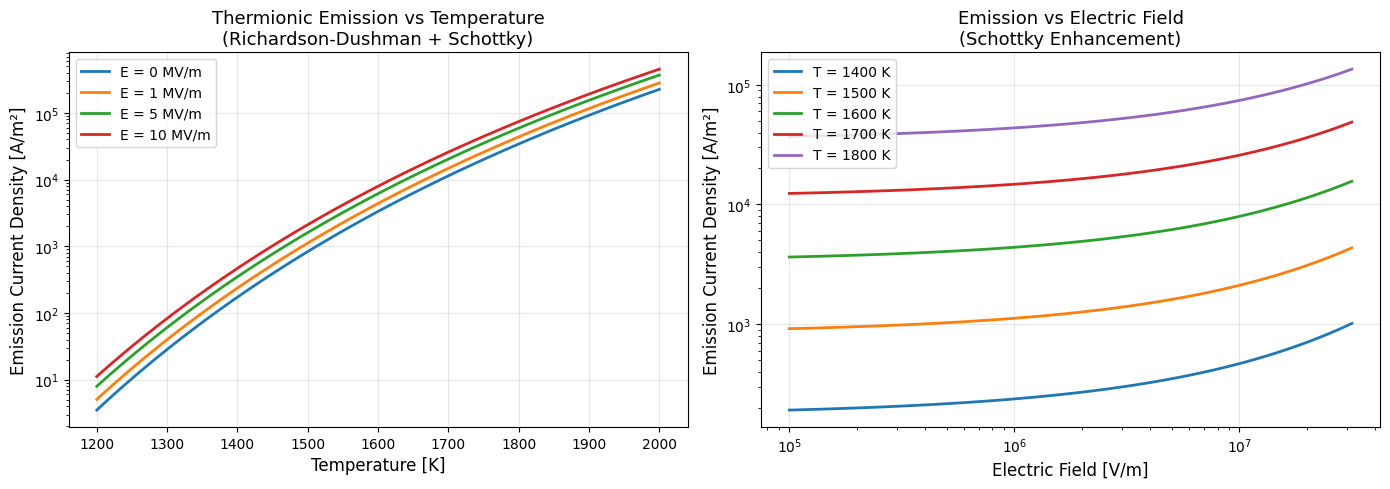

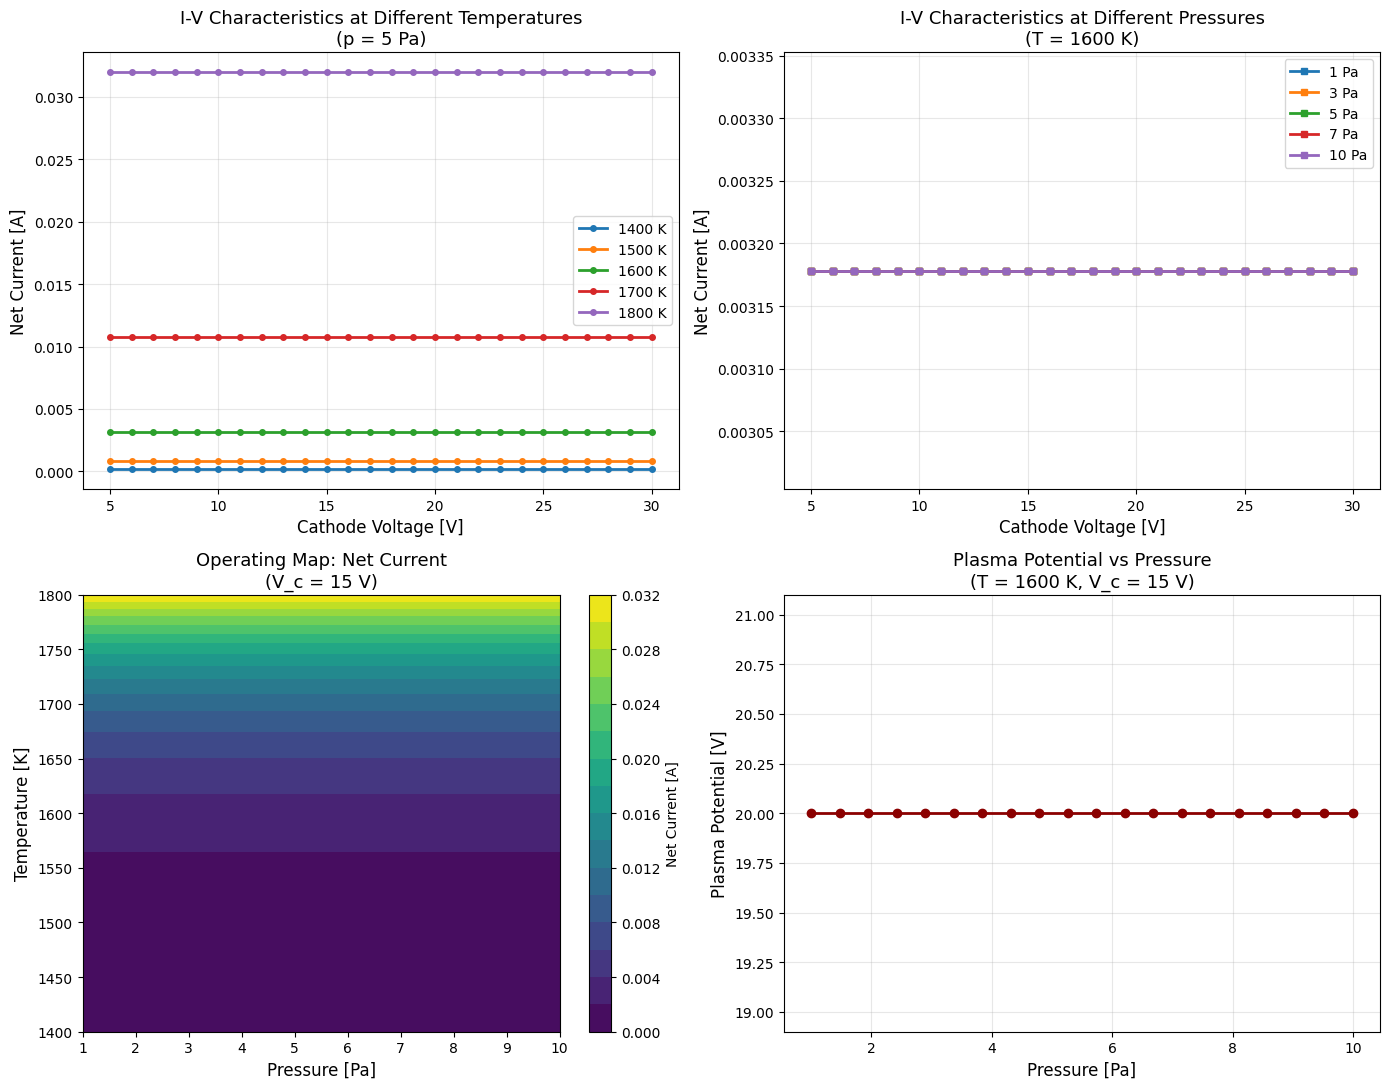

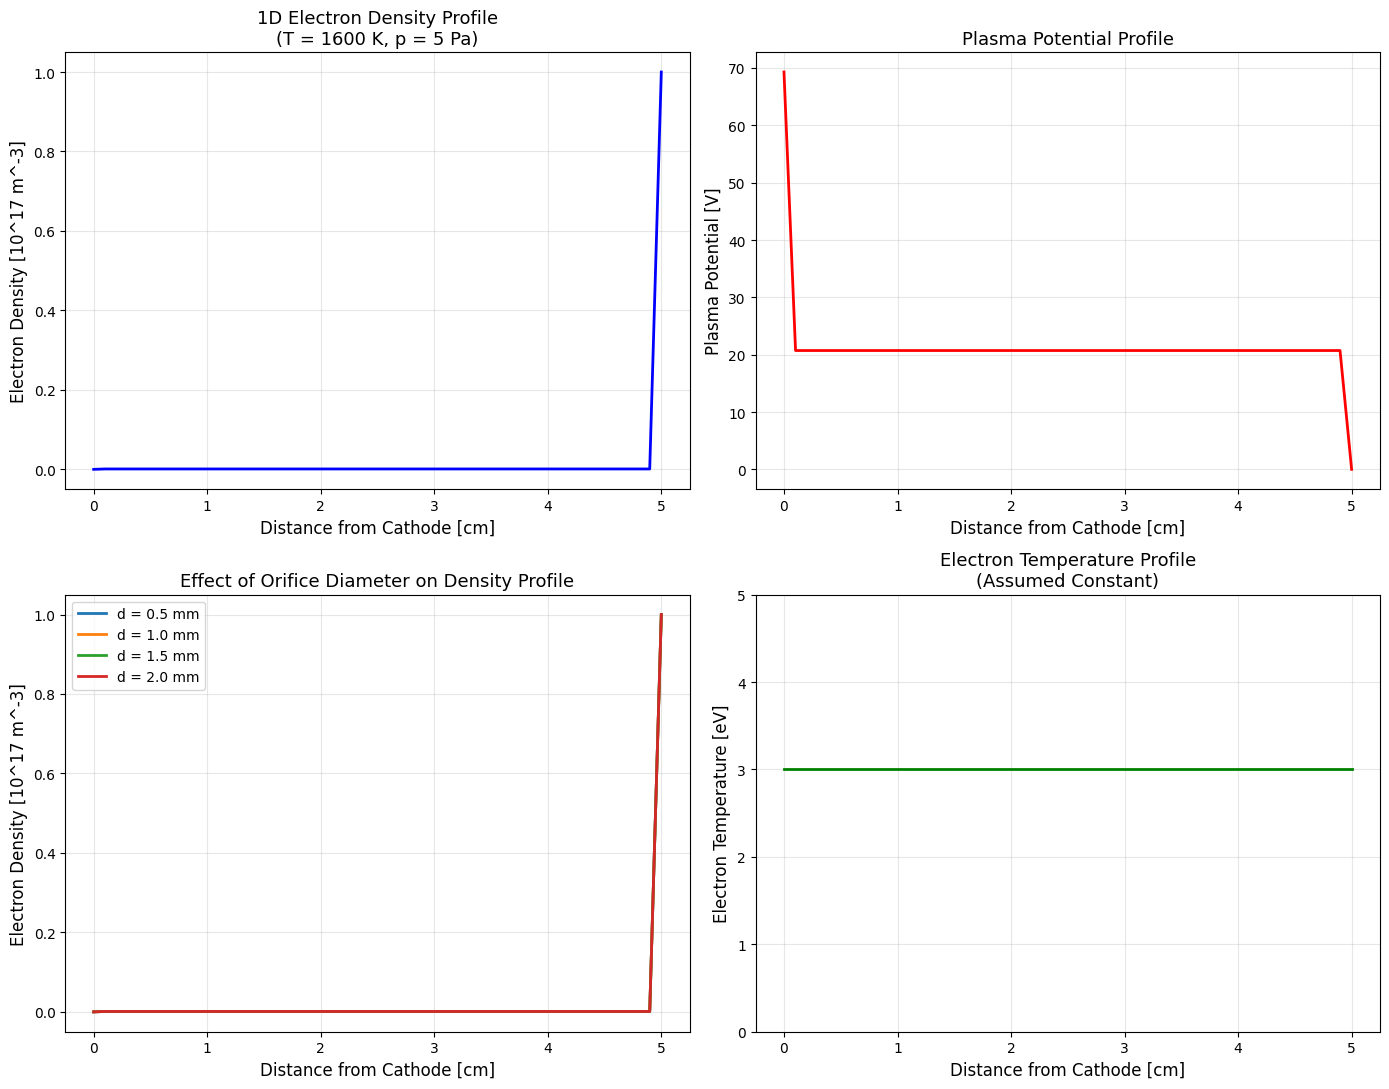

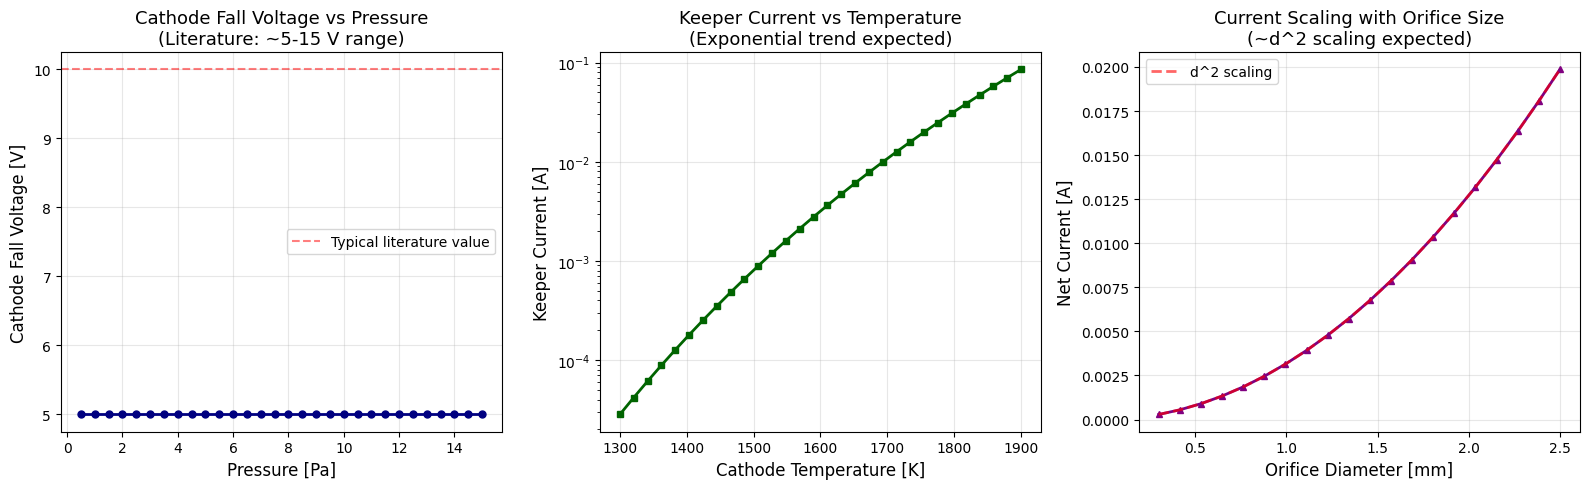

In [29]:
# MAIN EXECUTION


if __name__ == "__main__":
    print("="*70)
    print("ELECTRON SOURCE NUMERICAL MODELING")
    print("="*70)
    print()

    # Task 1: Emission Model
    print("Task 1: Generating emission curves")
    plot_task1_emission_curves()

    # Task 2: Sheath Current Balance
    print("\nTask 2: Computing I-V characteristics")
    plot_task2_iv_characteristics()

    # Task 3: 1D Plasma Column
    print("\nTask 3: Solving 1D plasma profiles")
    plot_task3_1d_profiles()

    # Task 4: Validation
    print("\nTask 4: Generating validation plots")
    plot_validation_trends()

    # Example operating point calculation
    print("\n" + "="*70)
    print("EXAMPLE OPERATING POINT")
    print("="*70)

    sim = ElectronSourceSimulation(d_orifice=1e-3)
    result = sim.solve_operating_point(T=1600, V_c=15, pressure=5.0)

    print(f"\nOperating Conditions:")
    print(f"  Temperature:      1600 K")
    print(f"  Cathode Voltage:  15 V")
    print(f"  Pressure:         5 Pa")
    print(f"  Orifice Diameter: 1 mm")
    print(f"\nResults:")
    print(f"  Sheath Voltage:   {result['V_sheath']:.2f} V")
    print(f"  Plasma Potential: {result['V_p']:.2f} V")
    print(f"  Emission Current: {result['I_em']:.4f} A")
    print(f"  Ion Current:      {result['I_ion']:.4f} A")
    print(f"  Net Current:      {result['I_net']:.4f} A")
    print(f"  Plasma Density:   {result['n_plasma']:.2e} m^-3")

    print("\n" + "="*70)
    print("All plots generated successfully!")
    print("="*70)